In [1]:
%matplotlib inline

In [149]:
from control_tools.axion_instruments import Hexapod, Positioner, VNA, Switch_Board, Actuator
from data_tools.data_control import data_write
from config_tools.config_files import config_files
from control_tools.control_procedures import alignment, analyze_data
import pyvisa as pv
import numpy as np
import matplotlib.pyplot as plt
import serial
import pandas as pd
from scipy.optimize import curve_fit
import polyplotter as pp
from functools import partial

In [150]:
rm = pv.ResourceManager()
    
Pos = Positioner('192.168.254.23', group_name='Group1', stage_name='Group1.Pos',
                 username='Administrator', password='Administrator', 
                 default_velocity=5, default_increment=1)
    
Hex = Hexapod('192.168.254.85', 
              username='Administrator', password='Administrator', groupname='HEXAPOD',
              port=5001, timeout=10, extra_triggers=0, xps=Pos.get_xps(), default_velocity=0.1) #need both Newport devices to use the same xps

Ant = Actuator(host = '192.168.254.23',                                #Create an object for the antenna actuator
               group_name = 'Group2',
               stage_name = 'Group2.Pos',
               username = 'Administrator', 
               password = 'Administrator')  

    
VNA = VNA(rm,name='GPIB::16::INSTR')

switch = Switch_Board(port='/dev/ttyUSB2', baudrate = 9600, bytesize = 8, timeout = 2, stopbits = serial.STOPBITS_ONE)
    
align = alignment(Hex, Pos, VNA)
analyze = analyze_data()


Connecting to socket: 0 ...
Connected to socket: 0
Reading system file with params: {'host': '192.168.254.23', 'username': 'Administrator', 'password': 'Administrator'}
Connecting to socket: 1 ...
Connected to socket: 1
Connecting to socket: 0 ...
Connected to socket: 0
Reading system file with params: {'host': '192.168.254.23', 'username': 'Administrator', 'password': 'Administrator'}


/home/user/anaconda3/envs/axion/lib/python3.8/site-packages/pyvisa_py/tcpip.py:121: UserWarning: TCPIP::hislip resource discovery requires the zeroconf package to be installed... try 'pip install zeroconf'
  warnings.warn(
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid descriptor
libgpib: invalid desc

trying
Connected to GPIB::16::INSTR


In [151]:
def collect_transmission(filename='output.txt'):
    switch.set_reflection_config()
    
    #VNA.set_freq_region(center = 7.563102261e9, span = 15.834002e6)

    freq, data = VNA.record_data_complex(name='CH1_S21_2')
    
    output = pd.DataFrame({'freq (Hz)': freq, 'resp': data})
    
    output.to_csv(filename,sep=',')

    

  

In [194]:
def plot_resonance(freq_array, data_array, name_array):

    fig1, ax1 = plt.subplots(1)
    fig2, ax2 = plt.subplots(1)
    fig3, ax3 = plt.subplots(1)

    for i in range(len(data_array)):
        print(i)

        ax1.plot(freq_array[i]/1e9,20*np.log10(np.abs(data_array[i])),label=name_array[i])
        ax1.set_xlabel('Frequency (GHz)')
        ax1.set_ylabel('|S21| (dB)')

        ax2.plot(freq_array[i]/1e9,np.unwrap(np.angle(data_array[i]))*180/np.pi,label=name_array[i])
        ax2.set_xlabel('Frequency (GHz)')
        ax2.set_ylabel('Phase (deg)')

        ax3.plot(np.real(data_array[i]), np.imag(data_array[i]),label=name_array[i])
        ax3.set_xlabel('Re(S21)')
        ax3.set_ylabel('Im(S21)')
       
    ax1.legend()
    ax2.legend()
    ax3.legend()
    fig3.gca().set_aspect('equal')

In [201]:
filename = 'testing_vna_power_neg30dBm.txt'

collect_transmission(filename=filename)

Togglingswitch1 open, chip 4

5 pin 3

Done.

Togglingswitch2 open, chip 4

5 pin 1

Done.

Togglingswitch3 open, chip 4

4 pin 3

Done.

Togglingswitch4 open, chip 4

4 pin 1

Done.

Togglingswitch5 open, chip 4

3 pin 3

Done.

Sending command: SENS:FREQ:STAR?;STOP?
Response Received
Sending command: SENSe1:SWEep:POIN?
Response Received
Sending command: CALC:PAR:SEL 'CH1_S21_2'
Response Received
Sending command: CALC:DATA? SDATA
Response Received


0
1
2
3
4
5
6
7


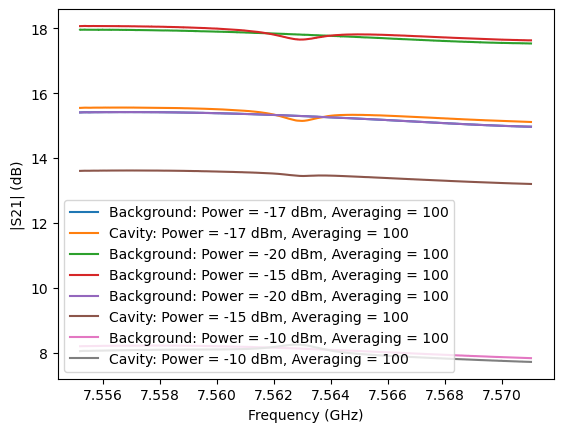

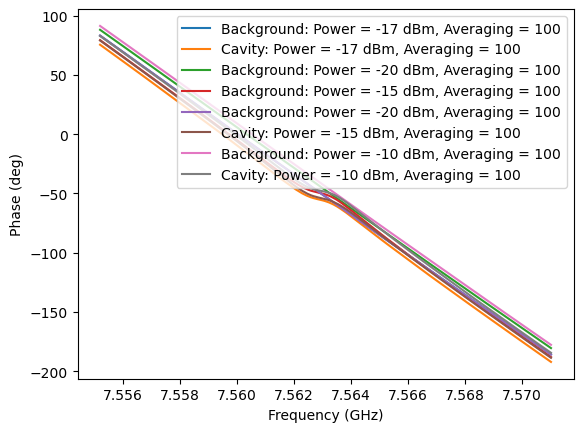

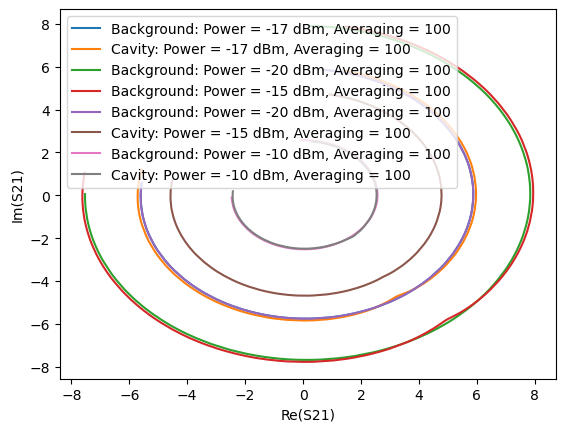

In [44]:
data_neg17dBm_average_100 = pd.read_csv('power_-17dBm_average_100.txt')
data_neg17dBm_average_100_freq = data_neg17dBm_average_100['freq (Hz)'].to_numpy(dtype=float)
data_neg17dBm_average_100_resp = data_neg17dBm_average_100['resp'].to_numpy(dtype=complex)

background_neg17dBm_average_100 = pd.read_csv('background_power_-17dBm_average_100.txt')
background_neg17dBm_average_100_freq = background_neg17dBm_average_100['freq (Hz)'].to_numpy(dtype=float)
background_neg17dBm_average_100_resp = background_neg17dBm_average_100['resp'].to_numpy(dtype=complex)

data_neg20dBm_average_100 = pd.read_csv('power_-20dBm_average_100.txt')
data_neg20dBm_average_100_freq = data_neg20dBm_average_100['freq (Hz)'].to_numpy(dtype=float)
data_neg20dBm_average_100_resp = data_neg20dBm_average_100['resp'].to_numpy(dtype=complex)

background_neg20dBm_average_100 = pd.read_csv('background_power_-20dBm_average_100.txt')
background_neg20dBm_average_100_freq = background_neg20dBm_average_100['freq (Hz)'].to_numpy(dtype=float)
background_neg20dBm_average_100_resp = background_neg20dBm_average_100['resp'].to_numpy(dtype=complex)

data_neg15dBm_average_100 = pd.read_csv('power_-15dBm_average_100.txt')
data_neg15dBm_average_100_freq = data_neg15dBm_average_100['freq (Hz)'].to_numpy(dtype=float)
data_neg15dBm_average_100_resp = data_neg15dBm_average_100['resp'].to_numpy(dtype=complex)

background_neg15dBm_average_100 = pd.read_csv('background_power_-15dBm_average_100.txt')
background_neg15dBm_average_100_freq = background_neg15dBm_average_100['freq (Hz)'].to_numpy(dtype=float)
background_neg15dBm_average_100_resp = background_neg15dBm_average_100['resp'].to_numpy(dtype=complex)

data_neg10dBm_average_100 = pd.read_csv('power_-10dBm_average_100.txt')
data_neg10dBm_average_100_freq = data_neg10dBm_average_100['freq (Hz)'].to_numpy(dtype=float)
data_neg10dBm_average_100_resp = data_neg10dBm_average_100['resp'].to_numpy(dtype=complex)

background_neg10dBm_average_100 = pd.read_csv('background_power_-10dBm_average_100.txt')
background_neg10dBm_average_100_freq = background_neg10dBm_average_100['freq (Hz)'].to_numpy(dtype=float)
background_neg10dBm_average_100_resp = background_neg10dBm_average_100['resp'].to_numpy(dtype=complex)

plot_resonance([background_neg17dBm_average_100_freq, data_neg17dBm_average_100_freq, background_neg20dBm_average_100_freq, data_neg20dBm_average_100_freq, background_neg15dBm_average_100_freq, data_neg15dBm_average_100_freq, background_neg10dBm_average_100_freq, data_neg10dBm_average_100_freq],
               [background_neg17dBm_average_100_resp, data_neg17dBm_average_100_resp, background_neg20dBm_average_100_resp, data_neg20dBm_average_100_resp, background_neg17dBm_average_100_resp, data_neg15dBm_average_100_resp, background_neg10dBm_average_100_resp, data_neg10dBm_average_100_resp],
               ['Background: Power = -17 dBm, Averaging = 100', 'Cavity: Power = -17 dBm, Averaging = 100', 'Background: Power = -20 dBm, Averaging = 100', 'Background: Power = -15 dBm, Averaging = 100', 'Background: Power = -20 dBm, Averaging = 100', 'Cavity: Power = -15 dBm, Averaging = 100', 'Background: Power = -10 dBm, Averaging = 100', 'Cavity: Power = -10 dBm, Averaging = 100'])

0
1
2
3


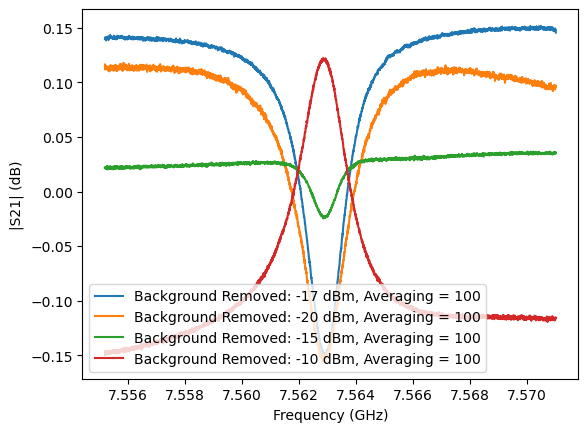

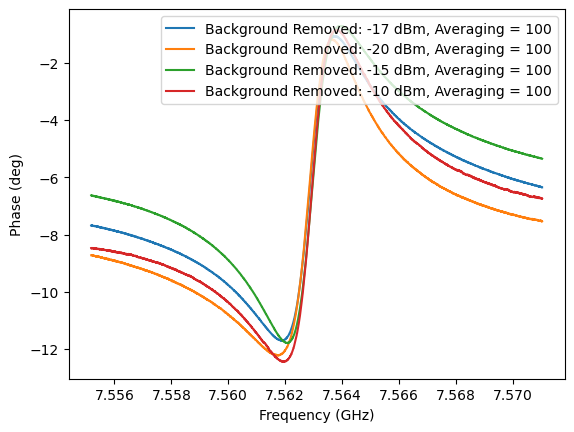

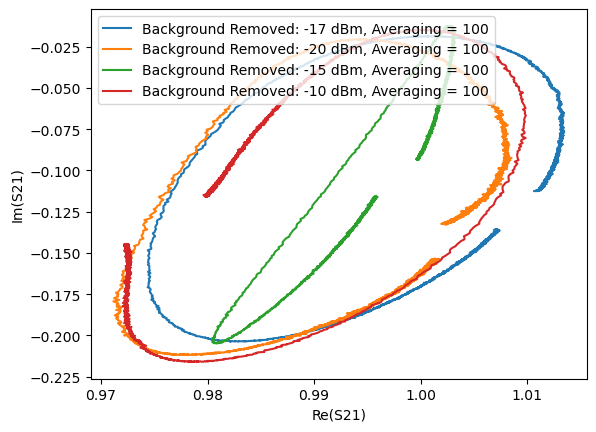

In [50]:
no_background_neg17dBm_average_100_resp = data_neg17dBm_average_100_resp / background_neg17dBm_average_100_resp

no_background_neg20dBm_average_100_resp = data_neg20dBm_average_100_resp / background_neg20dBm_average_100_resp

no_background_neg15dBm_average_100_resp = data_neg15dBm_average_100_resp / background_neg15dBm_average_100_resp

no_background_neg10dBm_average_100_resp = data_neg10dBm_average_100_resp / background_neg10dBm_average_100_resp

plot_resonance([data_neg17dBm_average_100_freq, data_neg17dBm_average_100_freq, data_neg15dBm_average_100_freq, data_neg17dBm_average_100_freq],
               [no_background_neg17dBm_average_100_resp, no_background_neg20dBm_average_100_resp, no_background_neg15dBm_average_100_resp, no_background_neg10dBm_average_100_resp],
               ['Background Removed: -17 dBm, Averaging = 100','Background Removed: -20 dBm, Averaging = 100','Background Removed: -15 dBm, Averaging = 100', 'Background Removed: -10 dBm, Averaging = 100'])

0


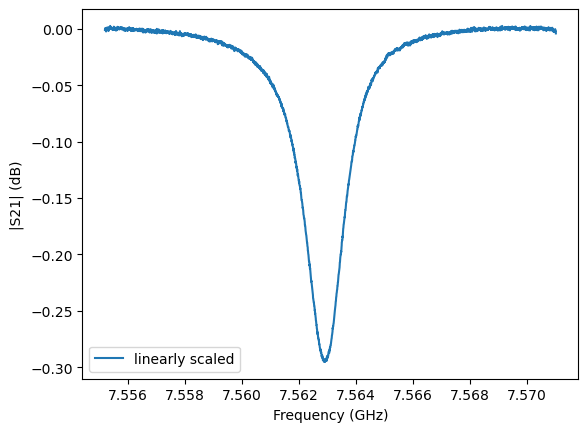

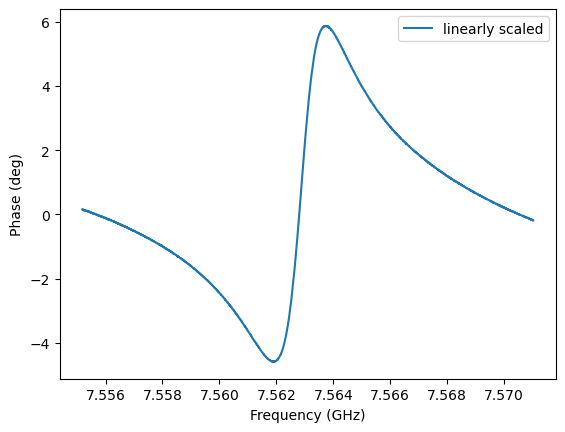

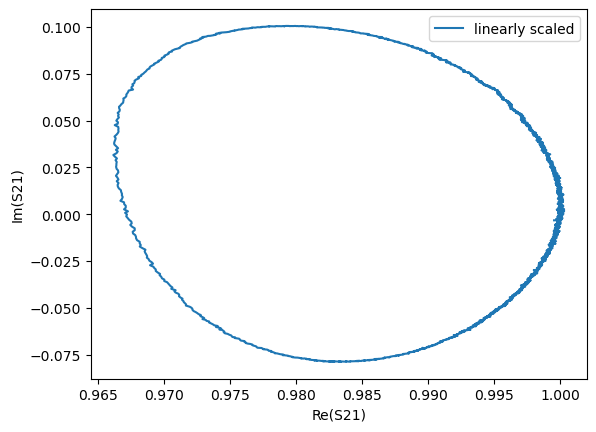

In [57]:
def linear(f, m, b):
    return m*f+b

neg17_freq_200 = np.append(data_neg17dBm_average_100_freq[0:199], data_neg17dBm_average_100_freq[len(data_neg17dBm_average_100_freq)-201:])
neg17_resp_200 = np.append(no_background_neg17dBm_average_100_resp[0:199], no_background_neg17dBm_average_100_resp[len(data_neg17dBm_average_100_freq)-201:])
neg17_mag_200 = np.abs(neg17_resp_200)
neg17_phase_200 = np.angle(neg17_resp_200)

popt_mag = curve_fit(linear, neg17_freq_200, neg17_mag_200)
popt_phase = curve_fit(linear, neg17_freq_200, neg17_phase_200)

neg17_linear_mag = linear(data_neg17dBm_average_100_freq, popt_mag[0][0], popt_mag[0][1])
neg17_linear_phase = linear(data_neg17dBm_average_100_freq, popt_phase[0][0], popt_phase[0][1])
neg17_linear_resp = neg17_linear_mag*np.exp(1j*neg17_linear_phase)


linearly_scaled_neg17dBm_average_100_resp = no_background_neg17dBm_average_100_resp / neg17_linear_resp

plot_resonance([data_neg17dBm_average_100_freq],
               [linearly_scaled_neg17dBm_average_100_resp],
               ['linearly scaled'])

In [86]:
def residuals(f, *args, func=None, data=None):
    return np.abs(data-func(f, *args))**2

def resonator_fit(freqs, data, func, p0, plot=True):
    popt, pcov = curve_fit(partial(residuals, data=data, func=func), freqs, 0*freqs, p0=p0)
    if plot:
        plot_data_fit(freqs, data, func, popt)
    return popt

def plot_data_fit(x, data, fitf, popt):
    plt.figure()
    smooth_x = np.linspace(x[0], x[-1], 10000)
    fit = fitf(smooth_x, *popt)
    fit_pts = fitf(x, *popt)
    f1 = plt.figure()
    ax1 = f1.subplots()
    f2 = plt.figure()
    ax2 = f2.subplots()
    f3 = plt.figure()
    ax3 = f3.subplots()
    axs = (ax1, ax2, ax3)
    plot_complex(x, data, fmt='k.', axs=axs)
    plot_complex(smooth_x, fit, fmt='r--', axs=axs)
    
def plot_complex(x, data, fmt='k.', axs=None):
    if axs is None:
        f1 = plt.figure()
        ax1 = f1.subplots()
        f2 = plt.figure()
        ax2 = f2.subplots()
        f3 = plt.figure()
        ax3 = f3.subplots()
    else:
        ax1, ax2, ax3 = axs
    ax1.plot(x, np.abs(data), fmt)
    ax2.plot(x, np.unwrap(np.angle(data)), fmt)
    ax3.plot(np.real(data), np.imag(data), fmt)
    
def matt_linear_resonator(f, f_0, Q_0, beta):
    return 1 - (beta / (1+beta)) * 1/(1+2j*Q_0/beta*(f-f_0)/f_0)

0
1


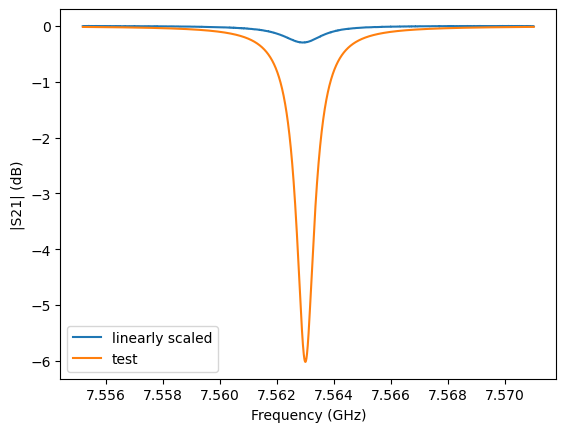

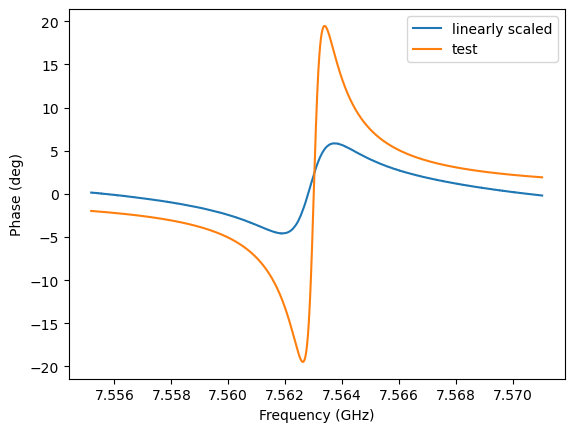

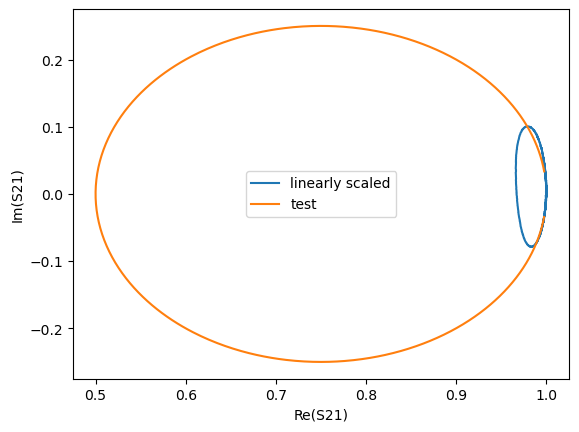

In [148]:
f0 = 7.563e9
Q0 = 7000
beta = 1

test_resp = matt_linear_resonator(data_neg17dBm_average_100_freq, f0, Q0, beta)


plot_resonance([data_neg17dBm_average_100_freq, data_neg17dBm_average_100_freq],
               [linearly_scaled_neg17dBm_average_100_resp, test_resp],
               ['linearly scaled', 'test'])


#resonator_fit(data_neg17dBm_average_100_freq, linearly_scaled_neg17dBm_average_100_resp, p0=[7.77655e9, 7000, 0.3], func=matt_linear_resonator)

0
1
2
3
4


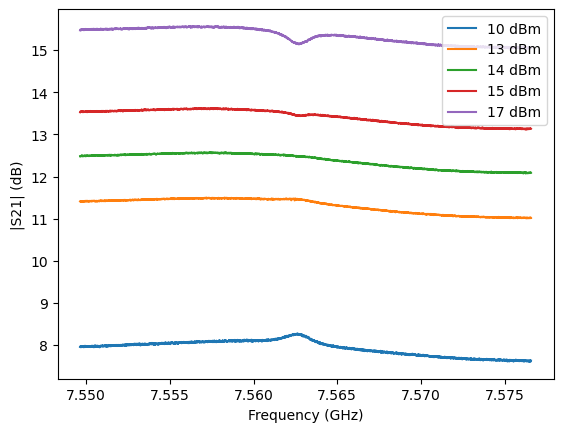

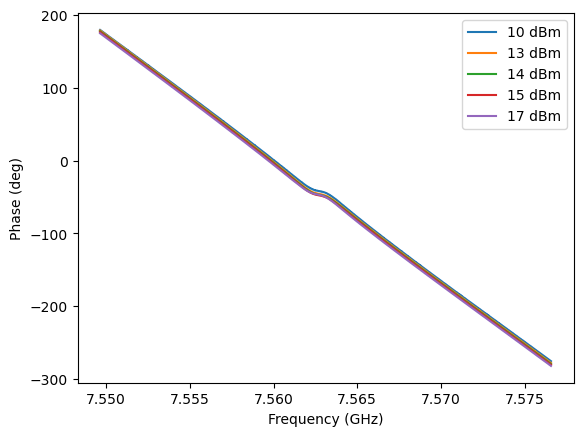

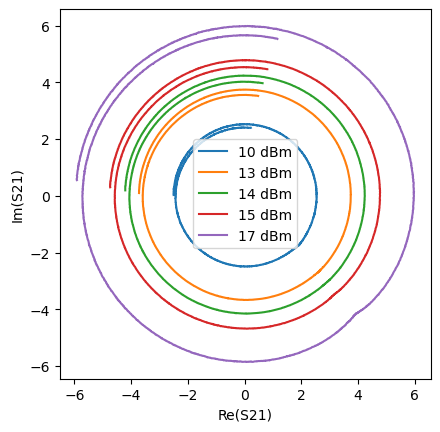

In [198]:
#reflection measurements with amplifier

amp_neg10dBm = pd.read_csv('testing_vna_power_neg10dBm.txt')
amp_neg10dBm_freq = amp_neg10dBm['freq (Hz)'].to_numpy(dtype=float)
amp_neg10dBm_resp = amp_neg10dBm['resp'].to_numpy(dtype=complex)

amp_neg13dBm = pd.read_csv('testing_vna_power_neg13dBm.txt')
amp_neg13dBm_freq = amp_neg13dBm['freq (Hz)'].to_numpy(dtype=float)
amp_neg13dBm_resp = amp_neg13dBm['resp'].to_numpy(dtype=complex)

amp_neg14dBm = pd.read_csv('testing_vna_power_neg14dBm.txt')
amp_neg14dBm_freq = amp_neg14dBm['freq (Hz)'].to_numpy(dtype=float)
amp_neg14dBm_resp = amp_neg14dBm['resp'].to_numpy(dtype=complex)

amp_neg15dBm = pd.read_csv('testing_vna_power_neg15dBm.txt')
amp_neg15dBm_freq = amp_neg15dBm['freq (Hz)'].to_numpy(dtype=float)
amp_neg15dBm_resp = amp_neg15dBm['resp'].to_numpy(dtype=complex)

amp_neg17dBm = pd.read_csv('testing_vna_power_neg17dBm.txt')
amp_neg17dBm_freq = amp_neg17dBm['freq (Hz)'].to_numpy(dtype=float)
amp_neg17dBm_resp = amp_neg17dBm['resp'].to_numpy(dtype=complex)

plot_resonance([amp_neg10dBm_freq, amp_neg13dBm_freq, amp_neg14dBm_freq, amp_neg15dBm_freq, amp_neg17dBm_freq],
                [amp_neg10dBm_resp, amp_neg13dBm_resp, amp_neg14dBm_resp, amp_neg15dBm_resp, amp_neg17dBm_resp],
                ['10 dBm', '13 dBm', '14 dBm', '15 dBm', '17 dBm'])

0
1
2
3
4


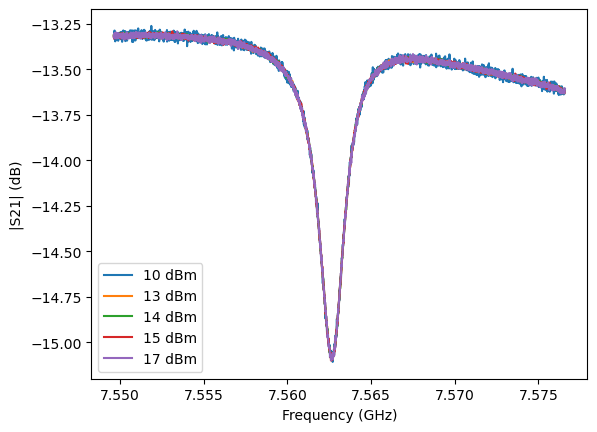

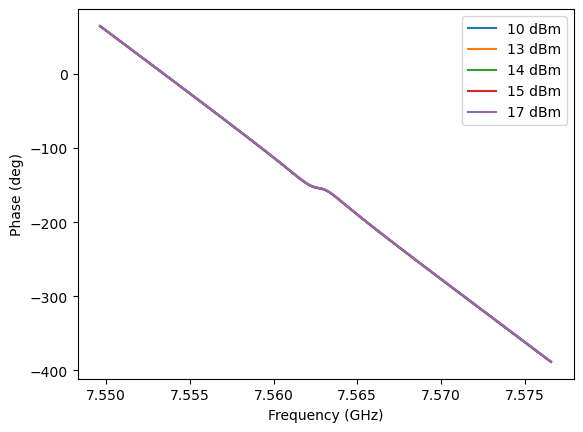

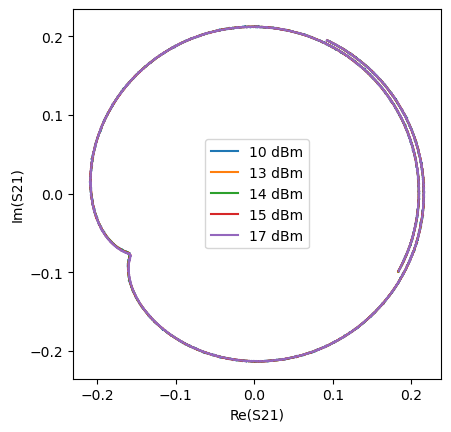

In [200]:
# no amplifier

no_amp_neg10dBm = pd.read_csv('testing_vna_power_no_amp_neg10dBm.txt')
no_amp_neg10dBm_freq = no_amp_neg10dBm['freq (Hz)'].to_numpy(dtype=float)
no_amp_neg10dBm_resp = no_amp_neg10dBm['resp'].to_numpy(dtype=complex)

no_amp_neg13dBm = pd.read_csv('testing_vna_power_no_amp_neg13dBm.txt')
no_amp_neg13dBm_freq = no_amp_neg13dBm['freq (Hz)'].to_numpy(dtype=float)
no_amp_neg13dBm_resp = no_amp_neg13dBm['resp'].to_numpy(dtype=complex)

no_amp_neg14dBm = pd.read_csv('testing_vna_power_no_amp_neg14dBm.txt')
no_amp_neg14dBm_freq = no_amp_neg14dBm['freq (Hz)'].to_numpy(dtype=float)
no_amp_neg14dBm_resp = no_amp_neg14dBm['resp'].to_numpy(dtype=complex)

no_amp_neg15dBm = pd.read_csv('testing_vna_power_no_amp_neg15dBm.txt')
no_amp_neg15dBm_freq = no_amp_neg15dBm['freq (Hz)'].to_numpy(dtype=float)
no_amp_neg15dBm_resp = no_amp_neg15dBm['resp'].to_numpy(dtype=complex)

no_amp_neg17dBm = pd.read_csv('testing_vna_power_no_amp_neg17dBm.txt')
no_amp_neg17dBm_freq = no_amp_neg17dBm['freq (Hz)'].to_numpy(dtype=float)
no_amp_neg17dBm_resp = no_amp_neg17dBm['resp'].to_numpy(dtype=complex)

plot_resonance([no_amp_neg10dBm_freq, no_amp_neg13dBm_freq, no_amp_neg14dBm_freq, no_amp_neg15dBm_freq, no_amp_neg17dBm_freq],
                [no_amp_neg10dBm_resp, no_amp_neg13dBm_resp, no_amp_neg14dBm_resp, no_amp_neg15dBm_resp, no_amp_neg17dBm_resp],
                ['10 dBm', '13 dBm', '14 dBm', '15 dBm', '17 dBm'])

0
1
2


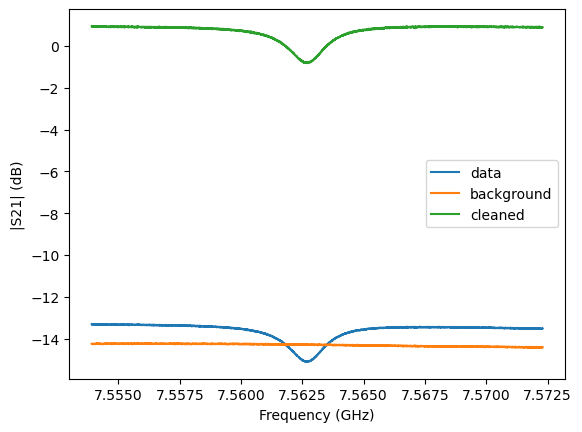

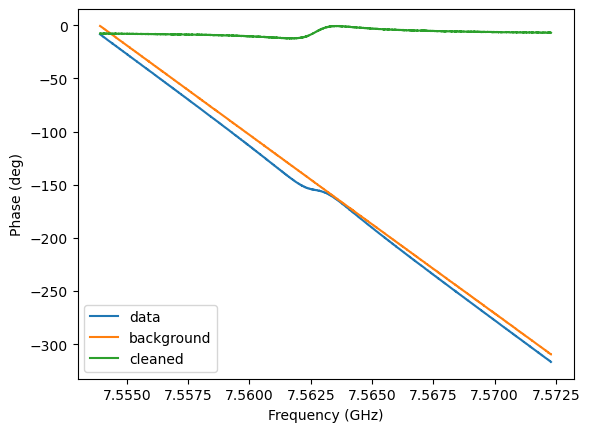

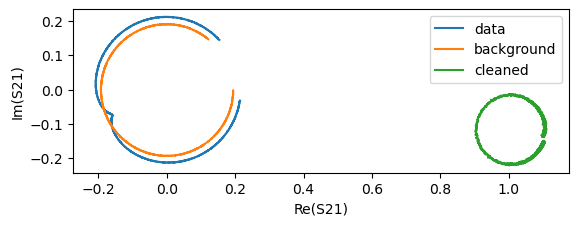

In [195]:
#no amplifier

data_neg17dBm = pd.read_csv('testing_vna_power_no_amp_neg17dBm_paired_to_background.txt')
data_neg17dBm_freq = data_neg17dBm['freq (Hz)'].to_numpy(dtype=float)
data_neg17dBm_resp = data_neg17dBm['resp'].to_numpy(dtype=complex)

background_neg17dBm = pd.read_csv('testing_vna_power_no_amp_neg17dBm_background.txt')
background_neg17dBm_freq = background_neg17dBm['freq (Hz)'].to_numpy(dtype=float)
background_neg17dBm_resp = background_neg17dBm['resp'].to_numpy(dtype=complex)

no_background_neg17dBm_resp = data_neg17dBm_resp / background_neg17dBm_resp


plot_resonance([data_neg17dBm_freq, data_neg17dBm_freq, data_neg17dBm_freq],
               [data_neg17dBm_resp, background_neg17dBm_resp, no_background_neg17dBm_resp],
               ['data','background','cleaned'])

array([7.56275429e+09, 4.60372887e+03, 1.12088268e-01, 2.89785914e+00,
       1.31390820e-01, 9.80253505e-02])

<Figure size 640x480 with 0 Axes>

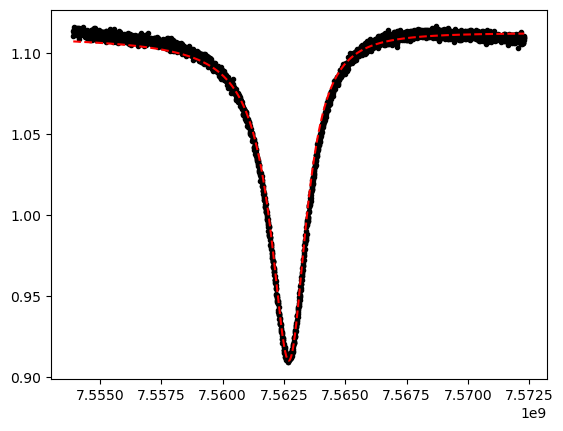

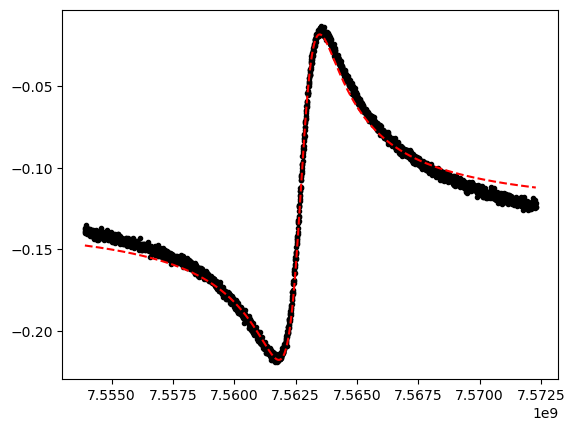

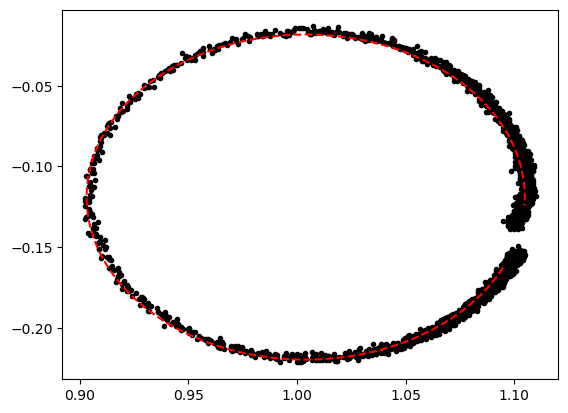

In [202]:
resonator_fit(data_neg17dBm_freq, no_background_neg17dBm_resp, p0=[7.563e9, 7000, 0.1, np.pi, 1, 0], func=pp.linear_resonator_rotated_offset)

0
1
2


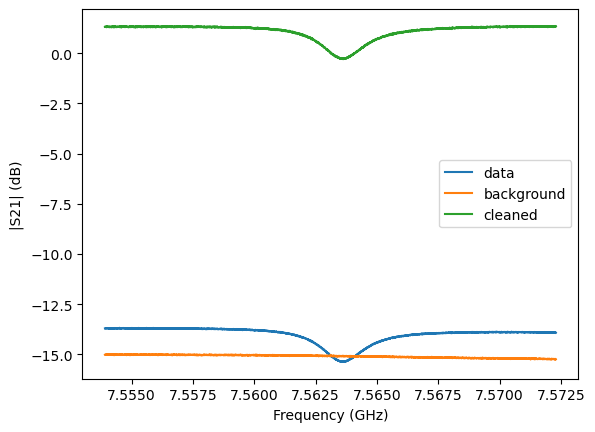

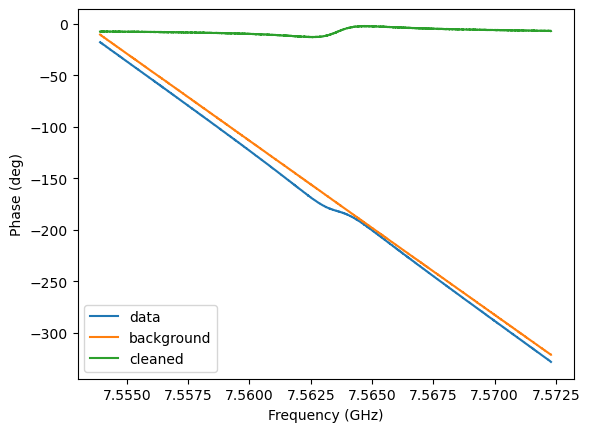

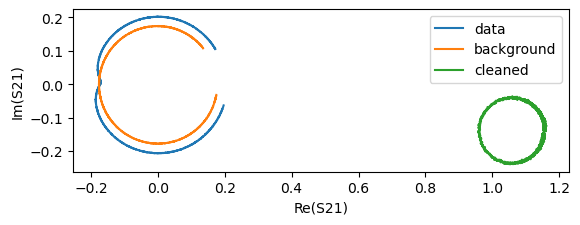

In [189]:
# medium antenna
#-17 dBm
ant_15mm_data = pd.read_csv('20230724_medium_antenna_15_mm.txt')
ant_15mm_freq = ant_15mm_data['freq (Hz)'].to_numpy(dtype=float)
ant_15mm_resp = ant_15mm_data['resp'].to_numpy(dtype=complex)

background_medium = pd.read_csv('20230724_medium_antenna_background.txt')
background_medium_freq = background_medium['freq (Hz)'].to_numpy(dtype=float)
background_medium_resp = background_medium['resp'].to_numpy(dtype=complex)

no_background_15_mm = ant_15mm_resp / background_medium_resp

plot_resonance([ant_15mm_freq, ant_15mm_freq, ant_15mm_freq],
               [ant_15mm_resp, background_medium_resp, no_background_15_mm],
               ['data','background','cleaned'])

array([ 7.56357732e+09,  4.05146899e+03,  1.07898887e-01,  3.08318963e+00,
        1.56603468e-01, -8.43586816e-02])

<Figure size 640x480 with 0 Axes>

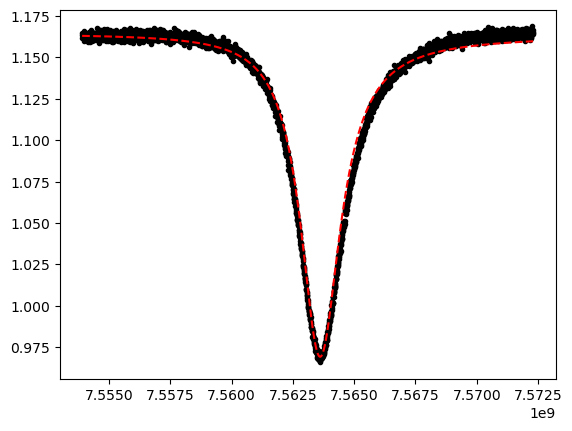

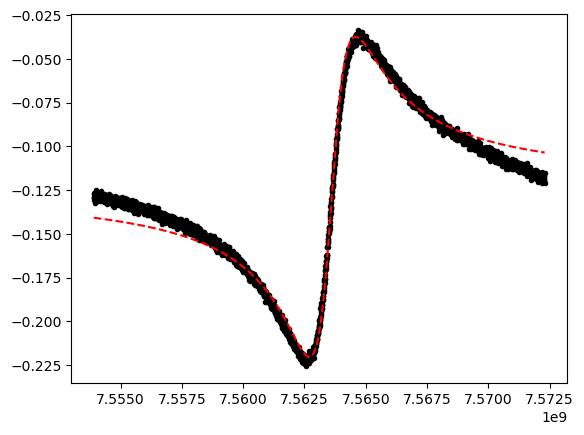

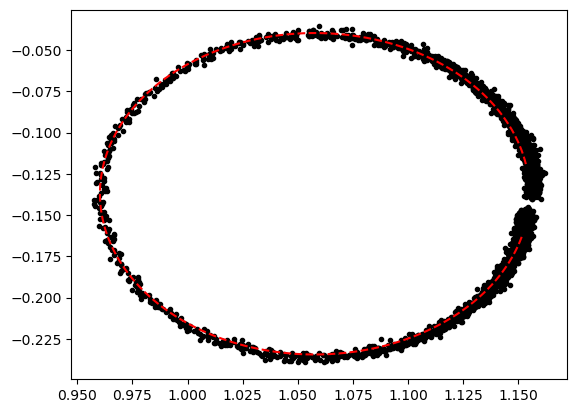

In [203]:
resonator_fit(ant_15mm_freq, no_background_15_mm, p0=[7.563e9, 7000, 0.2, np.pi, 1, 0], func=pp.linear_resonator_rotated_offset)

0
1
2


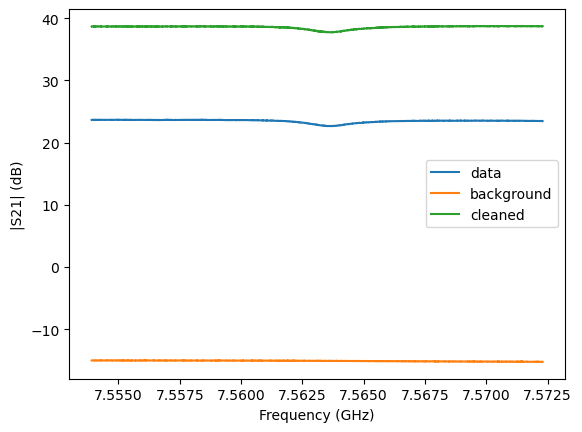

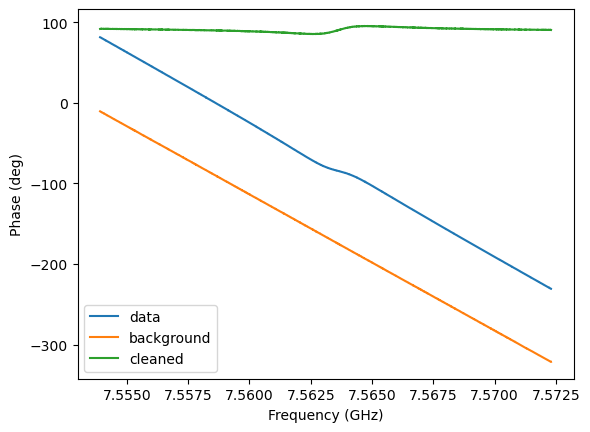

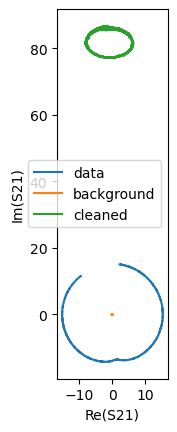

In [206]:
neg30dBm_data = pd.read_csv('testing_vna_power_neg30dBm.txt')
neg30dBm_freq = neg30dBm_data['freq (Hz)'].to_numpy(dtype=float)
neg30dBm_resp = neg30dBm_data['resp'].to_numpy(dtype=complex)

background_medium = pd.read_csv('20230724_medium_antenna_background.txt')
background_medium_freq = background_medium['freq (Hz)'].to_numpy(dtype=float)
background_medium_resp = background_medium['resp'].to_numpy(dtype=complex)

no_background_neg30dBm = neg30dBm_resp / background_medium_resp

plot_resonance([neg30dBm_freq, neg30dBm_freq, neg30dBm_freq],
               [neg30dBm_resp, background_medium_resp, no_background_neg30dBm],
               ['data','background','cleaned'])

array([ 7.56349127e+09,  6.21905369e+02, -8.46269584e-01,  1.77880566e+00,
       -2.19295331e+00,  8.72145095e+01])

<Figure size 640x480 with 0 Axes>

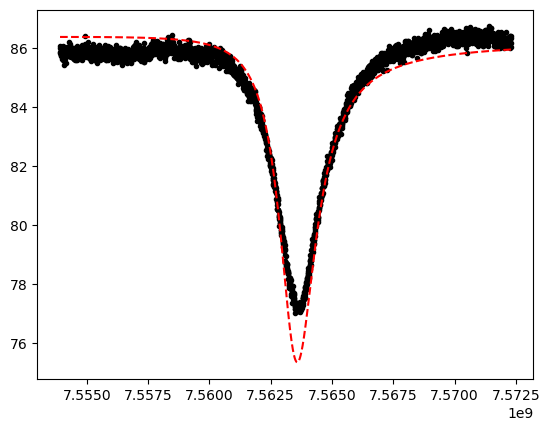

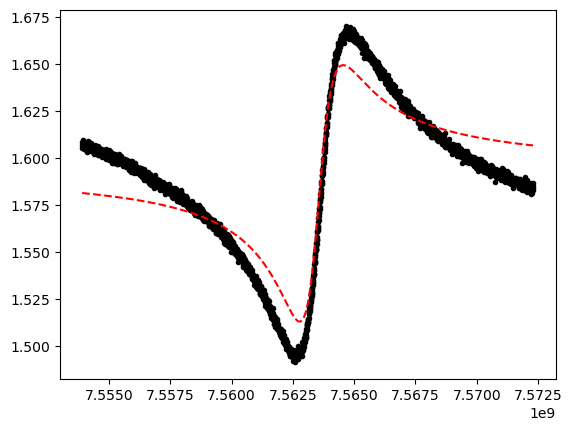

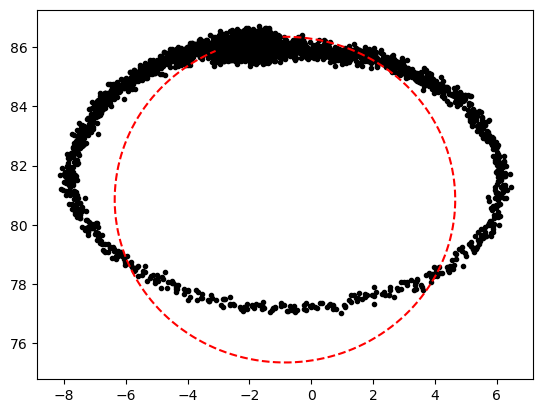

In [212]:
resonator_fit(neg30dBm_freq, no_background_neg30dBm, p0=[7.563e9, 7000, 0.2, -np.pi/2, 0, 82], func=pp.linear_resonator_rotated_offset)



